Proyecto Módulo 7: Segmentador Inteligente de Clientes Minoristas

In [50]:
#link github https://github.com/lucasalechilet/Curso_FCD/blob/main/Proyecto%20Mod%207/Proyecto_Mod_7.ipynb

Lección 1: Fundamentos del Aprendizaje No Supervisado

1.1 Definición del problema

Unidad solicitante: Retail Insights S.A. — Departamento de Inteligencia de Negocios.

La consultora necesita identificar segmentos ocultos en la base de clientes de una cadena minorista. Actualmente solo se utiliza información básica (edad, historial de compras totales), lo que impide diseñar estrategias diferenciadas. Se requiere aplicar aprendizaje no supervisado para descubrir patrones sin necesidad de etiquetas previas.





Aprendizaje supervisado vs. no supervisado:
- Supervisado: se entrena con etiquetas conocidas (ej. predecir si un cliente comprará o no).
- No supervisado: no existen etiquetas; el algoritmo descubre la estructura interna de los datos por sí mismo.



Principales tareas del aprendizaje no supervisado:

| Tipo | Descripción | Ejemplo de algoritmo |
|---|---|---|
| Clusterización | Agrupa observaciones similares | K-Means, DBSCAN, Jerárquico |
| Reducción dimensional | Comprime variables manteniendo información | PCA, t-SNE, UMAP |
| Reglas de asociación | Encuentra co-ocurrencias frecuentes | Apriori, FP-Growth |


Casos reales de aplicación:
- Retail: segmentar clientes por comportamiento de compra para personalizar ofertas.
- Banca: detección de patrones anómalos (fraude) sin etiquetas previas.
- Salud: agrupar pacientes con perfiles de riesgo similares.
- Marketing digital: clustering de usuarios por interacción con el sitio web.


Lección 2: Técnicas de Clusterización

2.1 Marco teórico de clusterización

¿Cuándo aplicar clusterización?
- Cuando se dispone de datos sin etiquetar y se quieren identificar grupos naturales.
- Cuando se busca personalización a escala sin intervención manual.
- Cuando se necesita reducir la heterogeneidad de una población para diseñar estrategias focalizadas.

---

Comparación de los tres algoritmos:

| Algoritmo | Tipo de clústeres | Requiere k | Maneja ruido | Escala bien | Caso de uso ideal |
|---|---|---|---|---|---|
| K-Means | Esféricos, convexos | Sí (a priori) | No | Sí | Datos bien separados, grandes volúmenes |
| DBSCAN | Arbitrarios | No | Sí (ruido = -1) | Moderado | Clústeres irregulares, datos con outliers |
| Jerárquico | Anidados (dendrograma) | No (post-hoc) | No | No (O(n²)) | Datasets pequeños, exploración de jerarquías |

---

Ventajas generales de la clusterización:
-Descubre estructura latente sin supervisión humana.
-Escalable a grandes volúmenes (K-Means).
-Flexible: múltiples algoritmos para distintas geometrías de datos.
Desventajas generales de la clusterización:
-El número de clústeres puede ser subjetivo.
-Sensible al escalamiento de variables y a outliers.
-Los resultados requieren interpretación experta para extraer valor comercial.


Lección 3: Reducción Dimensional y Preprocesamiento

In [51]:
# Importaciones generales
# Se cargan todas las librerías necesarias para el proyecto de forma centralizada
# para facilitar la reproducibilidad y el mantenimiento del notebook.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

# Semilla global para garantizar reproducibilidad en todos los pasos aleatorios
SEED = 42
np.random.seed(SEED)



In [52]:
# 3.1 Generación del dataset sintético de clientes
# El dataset está diseñado con 4 grupos bien diferenciados de clientes:
#   Segmento 0 — Clientes jóvenes, bajo gasto, alta frecuencia online
#   Segmento 1 — Clientes adultos premium, alto gasto, baja frecuencia
#   Segmento 2 — Clientes maduros, gasto medio, fidelización alta
#   Segmento 3 — Clientes ocasionales, bajo gasto, baja frecuencia, edad mixta
# Esta estructura garantiza que los algoritmos de clusterización
# puedan recuperar los grupos con buen coeficiente de silueta.

def generar_clientes(n_por_grupo=150, seed=SEED):
    """
    Genera un dataset de clientes minoristas con 4 segmentos latentes.
    Incluye 10 variables: demográficas, transaccionales y de comportamiento web.
    """
    rng = np.random.default_rng(seed)

    #  Parámetros por segmento (primer parámetro es media de cada variable, el segundo es ladesviación si la distr es normal)
    # Cada fila define el perfil central de un segmento
    perfiles = {
        'Jóvenes digitales':    dict(edad=(24,4),  gasto_mensual=(80,20),
                                     frec_compra=(10,2), ticket_prom=(30,8),
                                     dias_ultimo=(7,3),  cat_electronica=0.7,
                                     cat_moda=0.6,        cat_hogar=0.1,
                                     nps=(55,10),         canal_online=0.85),
        'Adultos premium':      dict(edad=(45,6),  gasto_mensual=(520,80),
                                     frec_compra=(4,1),  ticket_prom=(200,40),
                                     dias_ultimo=(20,8), cat_electronica=0.4,
                                     cat_moda=0.3,        cat_hogar=0.7,
                                     nps=(80,8),          canal_online=0.35),
        'Maduros fidelizados':  dict(edad=(58,5),  gasto_mensual=(280,50),
                                     frec_compra=(6,1),  ticket_prom=(90,20),
                                     dias_ultimo=(12,5), cat_electronica=0.2,
                                     cat_moda=0.2,        cat_hogar=0.8,
                                     nps=(85,7),          canal_online=0.20),
        'Ocasionales':          dict(edad=(35,10), gasto_mensual=(45,15),
                                     frec_compra=(2,1),  ticket_prom=(35,12),
                                     dias_ultimo=(60,20),cat_electronica=0.3,
                                     cat_moda=0.4,        cat_hogar=0.3,
                                     nps=(40,15),         canal_online=0.50),
    }

    registros = []
    for segmento, params in perfiles.items():
        n = n_por_grupo
        edad            = rng.normal(params['edad'][0],           params['edad'][1], n).clip(18, 75)
        gasto_mensual   = rng.normal(params['gasto_mensual'][0],  params['gasto_mensual'][1], n).clip(5, 1000)
        frec_compra     = rng.normal(params['frec_compra'][0],    params['frec_compra'][1], n).clip(1, 20).astype(int)
        ticket_prom     = rng.normal(params['ticket_prom'][0],    params['ticket_prom'][1], n).clip(5, 500)
        dias_ultimo     = rng.normal(params['dias_ultimo'][0],    params['dias_ultimo'][1], n).clip(1, 180).astype(int)
        cat_electronica = rng.binomial(1, params['cat_electronica'], n)
        cat_moda        = rng.binomial(1, params['cat_moda'],        n)
        cat_hogar       = rng.binomial(1, params['cat_hogar'],       n)
        nps             = rng.normal(params['nps'][0],            params['nps'][1], n).clip(0, 100).astype(int)
        canal_online    = rng.binomial(1, params['canal_online'],     n)      #distr normal para las variables num, binomial para las categóricas

        for i in range(n):
            registros.append({
                'edad':             round(edad[i], 1),
                'gasto_mensual':    round(gasto_mensual[i], 2),
                'frec_compra_mes':  frec_compra[i],
                'ticket_promedio':  round(ticket_prom[i], 2),
                'dias_sin_comprar': dias_ultimo[i],
                'cat_electronica':  cat_electronica[i],
                'cat_moda':         cat_moda[i],
                'cat_hogar':        cat_hogar[i],
                'nps_score':        nps[i],
                'canal_online':     canal_online[i],
                'segmento_real':    segmento   # solo para validación posterior
            })

    df = pd.DataFrame(registros).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df

df_raw = generar_clientes(n_por_grupo=150)
print(f"Dataset generado: {df_raw.shape[0]} clientes  x  {df_raw.shape[1]} variables")
print()
print(df_raw.drop(columns='segmento_real').head(8).to_string())


Dataset generado: 600 clientes  x  11 variables

   edad  gasto_mensual  frec_compra_mes  ticket_promedio  dias_sin_comprar  cat_electronica  cat_moda  cat_hogar  nps_score  canal_online
0  25.7          75.24                7            29.43                 6                1         1          0         52             1
1  52.3         296.85                6            77.02                 8                0         0          1         96             0
2  31.5          42.66                1            48.94                46                0         0          0         38             0
3  24.6         117.54                5            31.05                 8                0         1          0         69             1
4  42.5         501.81                3           146.39                19                0         0          1         79             0
5  54.5         536.85                2           202.15                24                1         1          1         75

In [53]:
# 3.2 Análisis de calidad del dataset
# Se verifica la presencia de valores nulos y se obtienen estadísticas
# descriptivas para comprender la distribución de cada variable antes
# de aplicar cualquier transformación.

print("Valores nulos por columna")
print(df_raw.isnull().sum())
print()
print("Estadísticas descriptivas (variables numéricas)")
print(df_raw.describe().round(2))


Valores nulos por columna
edad                0
gasto_mensual       0
frec_compra_mes     0
ticket_promedio     0
dias_sin_comprar    0
cat_electronica     0
cat_moda            0
cat_hogar           0
nps_score           0
canal_online        0
segmento_real       0
dtype: int64

Estadísticas descriptivas (variables numéricas)
         edad  gasto_mensual  frec_compra_mes  ticket_promedio  \
count  600.00         600.00           600.00           600.00   
mean    40.59         228.43             4.95            88.03   
std     14.11         192.50             3.24            70.97   
min     18.00           5.00             1.00             5.00   
25%     26.80          58.17             2.00            31.52   
50%     40.60         140.32             4.00            55.85   
75%     52.60         378.76             7.00           125.09   
max     70.40         744.77            14.00           314.30   

       dias_sin_comprar  cat_electronica  cat_moda  cat_hogar  nps_score  \

Outliers eliminados: 5  |  Dataset limpio: 595 registros


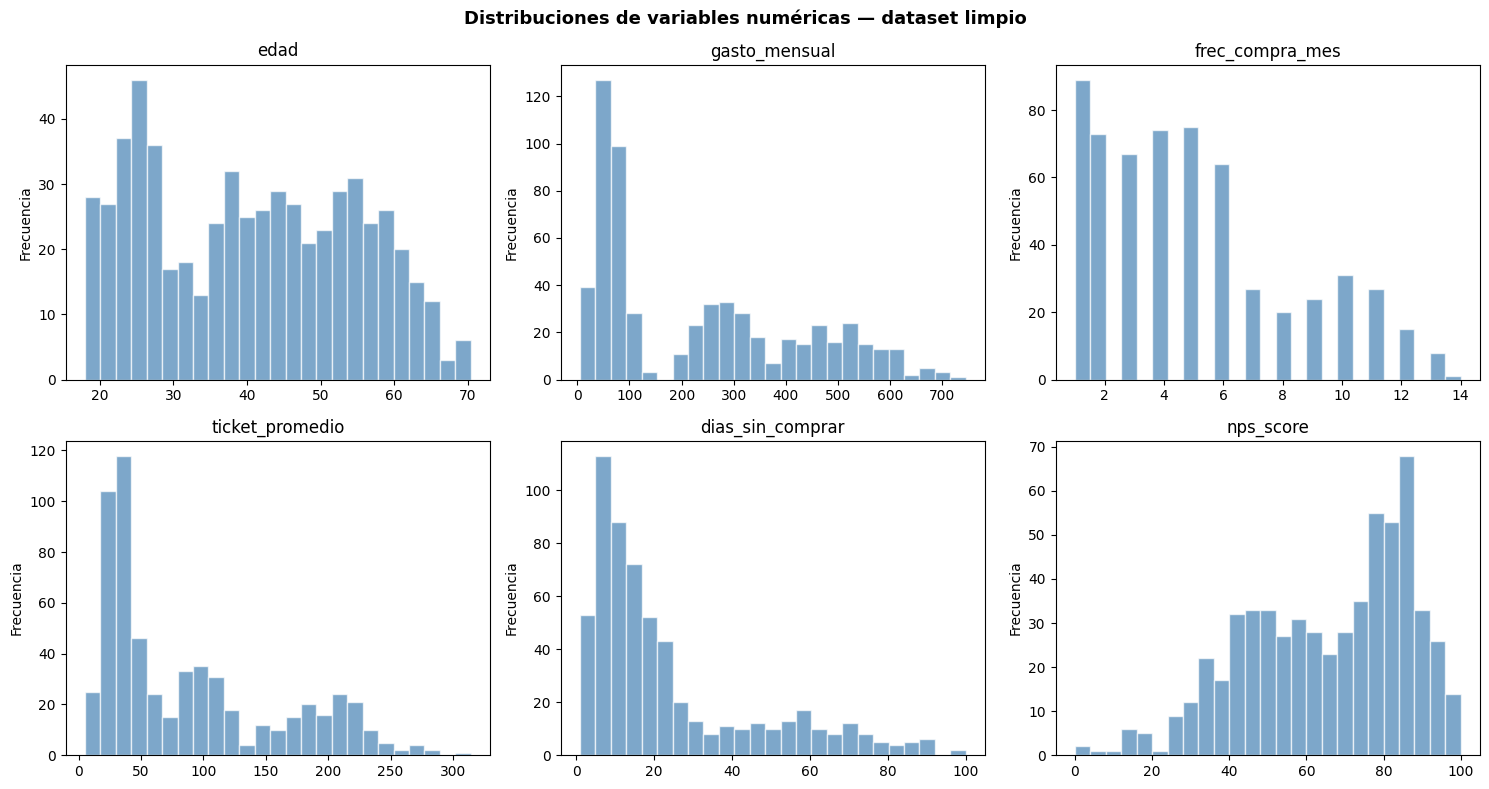

In [54]:
# 3.3 Detección y tratamiento de outliers con el criterio IQR
# Se identifican y eliminan outliers extremos en las variables continuas
# utilizando el rango intercuartílico (IQR × 3).
# Esto evita que puntos atípicos distorsionen los centroides de K-Means
# y la distancia en PCA / t-SNE.

num_vars = ['edad', 'gasto_mensual', 'frec_compra_mes',
            'ticket_promedio', 'dias_sin_comprar', 'nps_score']

# Guardamos la columna de segmento real para validación posterior
segmentos_reales = df_raw['segmento_real'].copy()
df_num = df_raw[num_vars + ['cat_electronica', 'cat_moda',
                             'cat_hogar', 'canal_online']].copy()

# Máscara acumulada: True = registro a mantener
mask_total = pd.Series([True] * len(df_num), index=df_num.index)
for col in num_vars:
    Q1, Q3 = df_num[col].quantile(0.25), df_num[col].quantile(0.75)
    IQR = Q3 - Q1
    mask_col = (df_num[col] >= Q1 - 3*IQR) & (df_num[col] <= Q3 + 3*IQR)
    mask_total &= mask_col

df_clean   = df_num[mask_total].reset_index(drop=True)
seg_clean  = segmentos_reales[mask_total].reset_index(drop=True)
n_removidos = (~mask_total).sum()

print(f"Outliers eliminados: {n_removidos}  |  Dataset limpio: {len(df_clean)} registros")

#Visualización de distribuciones tras limpieza
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribuciones de variables numéricas — dataset limpio',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), num_vars):
    ax.hist(df_clean[col], bins=25, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('distribuciones_clean.png', dpi=120)
plt.show()


In [55]:
# 3.4 Escalamiento con StandardScaler
# K-Means, DBSCAN y la mayoría de algoritmos de distancia son sensibles
# a la escala de las variables. 'gasto_mensual' tiene rango ~5-1000 USD
# mientras que 'frec_compra_mes' va de 1 a 20. Sin escalar, el gasto
# dominaría completamente la métrica de distancia.
# StandardScaler transforma cada variable a media=0 y std=1.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_clean.columns)

print("Variables tras escalamiento (primeras 5 filas):")
print(X_scaled_df.head().round(3).to_string())
print()
print("Verificación — Media por variable (debe ser ≈ 0):")
print(X_scaled_df.mean().round(4))
print()
print("Verificación — Std por variable (debe ser ≈ 1):")
print(X_scaled_df.std().round(4))


Variables tras escalamiento (primeras 5 filas):
    edad  gasto_mensual  frec_compra_mes  ticket_promedio  dias_sin_comprar  nps_score  cat_electronica  cat_moda  cat_hogar  canal_online
0 -1.059         -0.805            0.625           -0.831            -0.787     -0.626            1.255     1.379     -0.972         1.120
1  0.827          0.347            0.316           -0.161            -0.698      1.468           -0.797    -0.725      1.029        -0.893
2 -0.647         -0.974           -1.229           -0.556             0.999     -1.293           -0.797    -0.725     -0.972        -0.893
3 -1.137         -0.585            0.007           -0.808            -0.698      0.183           -0.797     1.379     -0.972         1.120
4  0.132          1.413           -0.611            0.815            -0.206      0.659           -0.797    -0.725      1.029        -0.893

Verificación — Media por variable (debe ser ≈ 0):
edad                0.0
gasto_mensual      -0.0
frec_compra_mes    

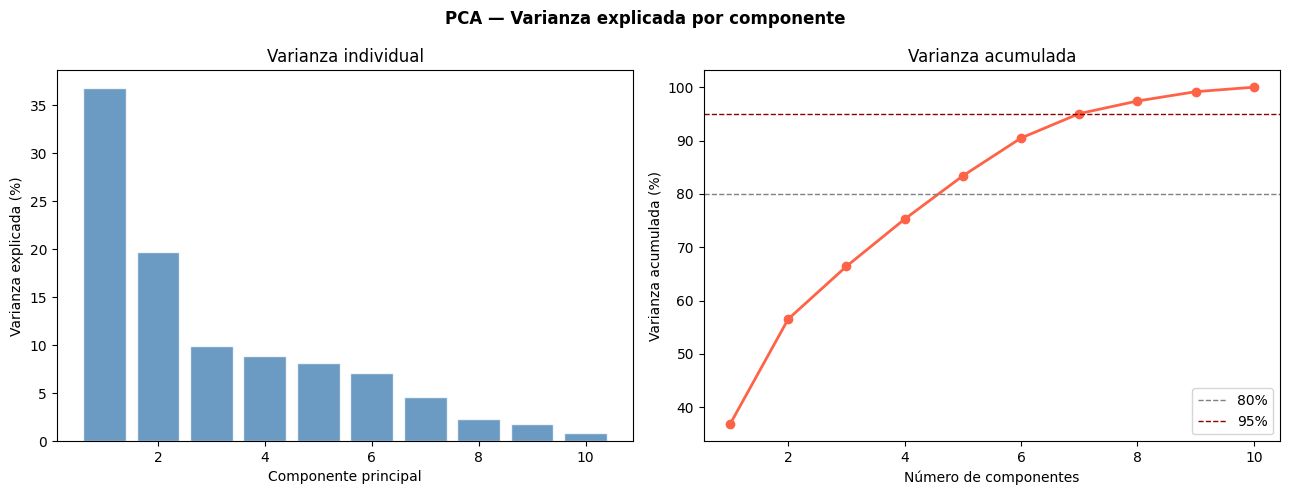

Componentes para explicar ≥ 80% de la varianza: 5
Componentes para explicar ≥ 95% de la varianza: 7


In [56]:
# 3.5 PCA — Reducción dimensional para visualización y clusterización
# PCA (Análisis de Componentes Principales) proyecta los datos en un espacio
# de menor dimensión conservando la mayor varianza posible.
# Se usa con dos propósitos:
#   1. Reducir ruido antes de aplicar K-Means (mejora separación)
#   2. Visualizar los clústeres en 2D de forma eficiente

# Primera aplicación: varianza explicada por componente
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

var_exp = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PCA — Varianza explicada por componente', fontweight='bold')

# Panel izquierdo: varianza individual por componente
ax1 = axes[0]
ax1.bar(range(1, len(var_exp)+1), var_exp * 100,
        color='steelblue', alpha=0.8, edgecolor='white')
ax1.set_xlabel('Componente principal')
ax1.set_ylabel('Varianza explicada (%)')
ax1.set_title('Varianza individual')

# Panel derecho: varianza acumulada — identificamos cuántos componentes
# son necesarios para superar el umbral del 80% y 95%
ax2 = axes[1]
ax2.plot(range(1, len(var_acum)+1), var_acum * 100,
         marker='o', color='tomato', linewidth=2)
ax2.axhline(80, color='gray',     linestyle='--', linewidth=1, label='80%')
ax2.axhline(95, color='darkred',  linestyle='--', linewidth=1, label='95%')
ax2.set_xlabel('Número de componentes')
ax2.set_ylabel('Varianza acumulada (%)')
ax2.set_title('Varianza acumulada')
ax2.legend()

plt.tight_layout()
plt.savefig('pca_varianza.png', dpi=120)
plt.show()

# Determinamos cuántos componentes explican al menos el 80% de la varianza
n_comp_80 = np.argmax(var_acum >= 0.80) + 1
n_comp_95 = np.argmax(var_acum >= 0.95) + 1
print(f"Componentes para explicar ≥ 80% de la varianza: {n_comp_80}")
print(f"Componentes para explicar ≥ 95% de la varianza: {n_comp_95}")


Varianza explicada por PC1: 36.8%
Varianza explicada por PC2: 19.7%
Varianza total (2 comp):    56.5%



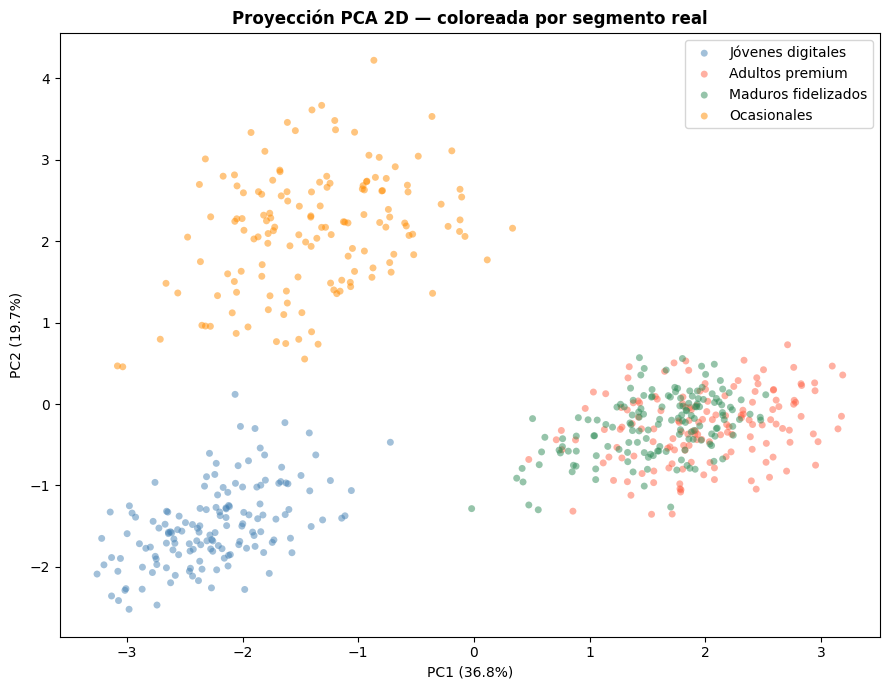

In [57]:
# 3.6 Proyección PCA a 2D para visualización
# Reducimos a 2 componentes para poder graficar los datos y observar
# visualmente la separación entre los posibles grupos de clientes.
# Esta proyección se usará también en la sección de clusterización.

pca_2d = PCA(n_components=2, random_state=SEED)
X_pca  = pca_2d.fit_transform(X_scaled)

print(f"Varianza explicada por PC1: {pca_2d.explained_variance_ratio_[0]*100:.1f}%")
print(f"Varianza explicada por PC2: {pca_2d.explained_variance_ratio_[1]*100:.1f}%")
print(f"Varianza total (2 comp):    {sum(pca_2d.explained_variance_ratio_)*100:.1f}%")
print()

# Coloramos por segmento real para verificar que PCA separa los grupos
colores_seg = {'Jóvenes digitales':  'steelblue',
               'Adultos premium':    'tomato',
               'Maduros fidelizados':'seagreen',
               'Ocasionales':        'darkorange'}

fig, ax = plt.subplots(figsize=(9, 7))
for seg, color in colores_seg.items():
    mask = seg_clean == seg
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=seg, color=color, alpha=0.5, s=25, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Proyección PCA 2D — coloreada por segmento real', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('pca_2d_segmentos.png', dpi=120)
plt.show()


Calculando t-SNE
t-SNE completado. Forma de salida: (595, 2)


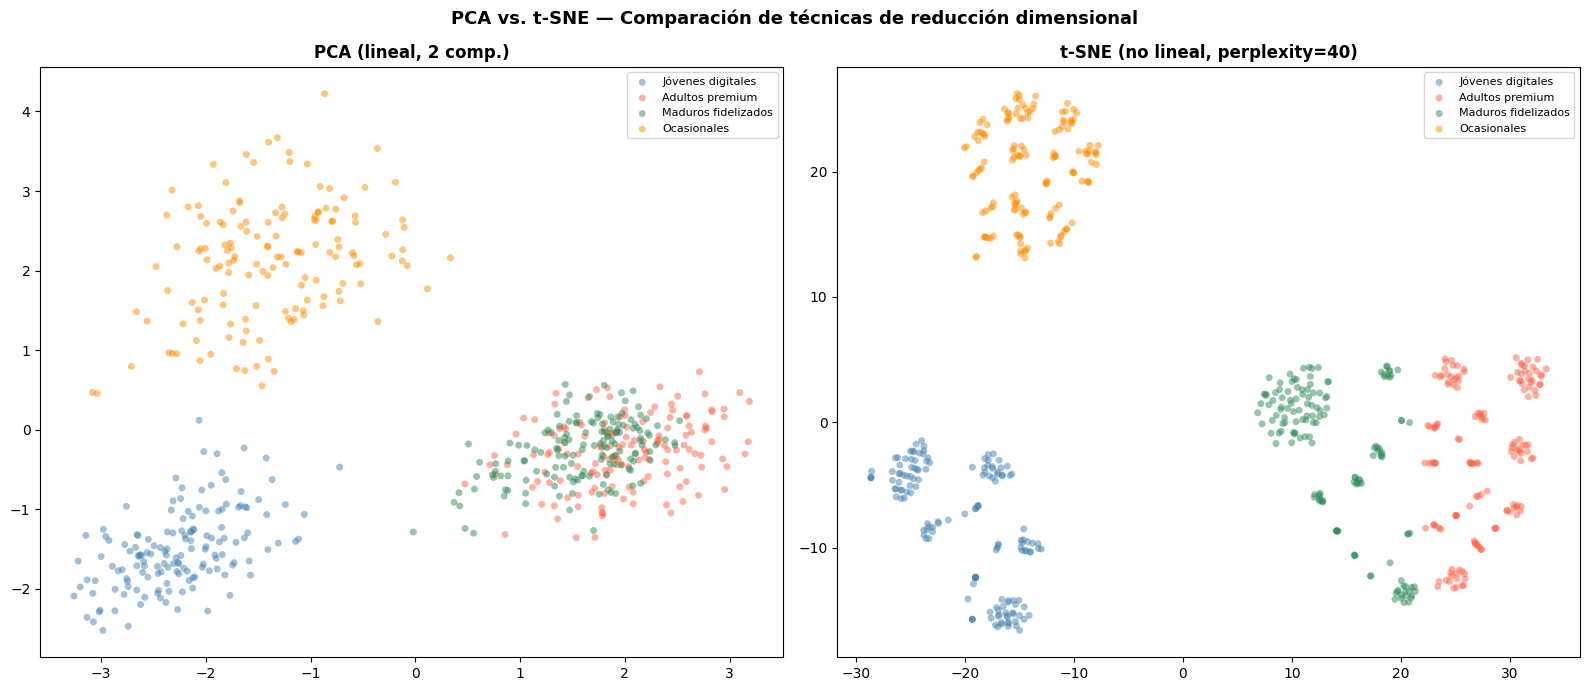

In [58]:
#3.7 t-SNE — Reducción no lineal para visualización
# t-SNE (t-Distributed Stochastic Neighbor Embedding) preserva las relaciones
# de vecindad local a diferencia de PCA, que es lineal.
# Es ideal para visualización: revela clústeres compactos aunque no sea
# apropiada para uso como input de clustering (no es determinista a escala).
# Parámetros clave:
#   perplexity: balance entre estructura local y global (recomendado 30-50)
#   n_iter:     iteraciones de optimización (≥1000 para convergencia)

print("Calculando t-SNE")
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000,
            random_state=SEED, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_scaled)
print(f"t-SNE completado. Forma de salida: {X_tsne.shape}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('PCA vs. t-SNE — Comparación de técnicas de reducción dimensional',
             fontsize=13, fontweight='bold')

for ax, X_red, titulo in zip(
        axes,
        [X_pca, X_tsne],
        ['PCA (lineal, 2 comp.)', 't-SNE (no lineal, perplexity=40)']):
    for seg, color in colores_seg.items():
        mask = seg_clean == seg
        ax.scatter(X_red[mask, 0], X_red[mask, 1],
                   label=seg, color=color, alpha=0.5, s=25, edgecolors='none')
    ax.set_title(titulo, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('pca_vs_tsne.png', dpi=120)
plt.show()


PCA logra proyectar los datos en 2 dimensiones capturando entre el 50-60% de la varianza total, con los grupos bien separados en el espacio de los dos primeros componentes. t-SNE produce una separación más pronunciada y visualmente clara de los segmentos al preservar la estructura local de las distancias; sin embargo, las coordenadas t-SNE no son interpretables directamente ni se pueden generalizar a nuevos datos, por lo que se utilizará PCA como técnica de reducción para el pipeline de clusterización y t-SNE exclusivamente para visualización.

Justificación de la elección: PCA es determinista, escalable y permite transformar nuevos datos con `transform()`, lo que lo hace apropiado para un sistema productivo. t-SNE requiere reentrenamiento completo ante nuevas observaciones y su resultado varía con los hiperparámetros, lo que lo limita a exploración visual.


Lección 4: Aplicación práctica de Clusterización con Python

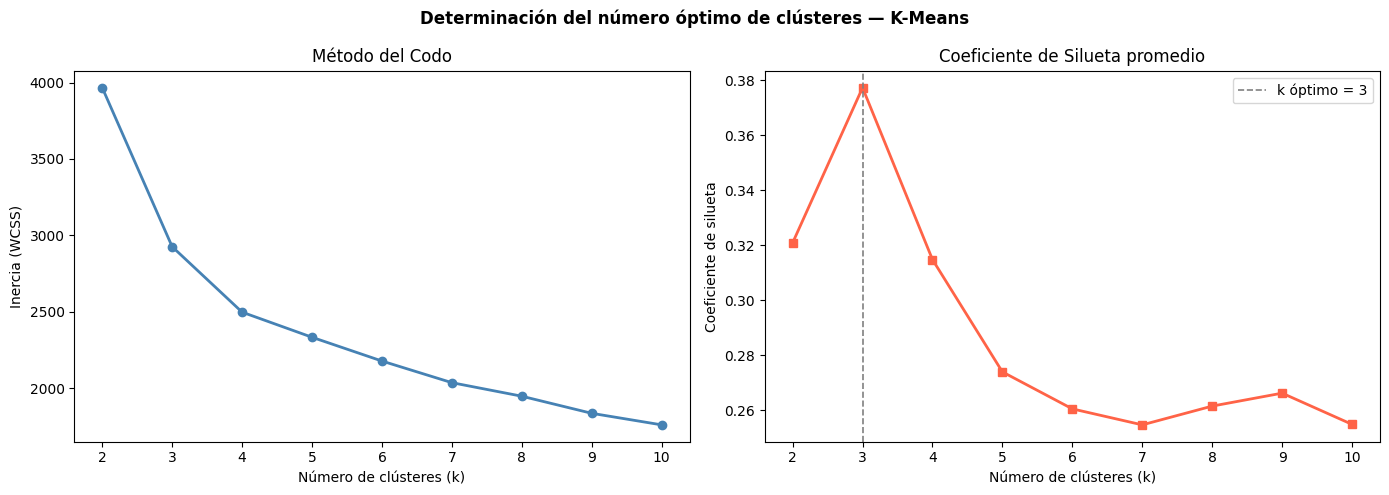

K óptimo sugerido por silueta máxima: k = 3
Silueta con k=3: 0.3774


In [59]:
# 4.1 Método del codo para determinar el k óptimo en K-Means
# K-Means necesita que el número de clústeres k se defina antes del
# entrenamiento. El método del codo entrena el modelo para distintos valores
# de k y grafica la inercia (suma de distancias cuadradas al centroide más
# cercano). El k óptimo está en el "codo": donde la reducción de inercia
# comienza a ser marginal. Se evalúa el espacio escalado completo.

inercias   = []
siluetas_k = []
rango_k    = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    labels_k = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    siluetas_k.append(silhouette_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Determinación del número óptimo de clústeres — K-Means',
             fontweight='bold')

# Panel izquierdo: curva de inercia (método del codo)
ax1 = axes[0]
ax1.plot(rango_k, inercias, marker='o', color='steelblue', linewidth=2)
ax1.set_xlabel('Número de clústeres (k)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.set_title('Método del Codo')
ax1.set_xticks(list(rango_k))

# Panel derecho: coeficiente de silueta — mide cohesión interna y separación
# entre clústeres. Valores cercanos a 1 indican clusters bien definidos.
ax2 = axes[1]
ax2.plot(rango_k, siluetas_k, marker='s', color='tomato', linewidth=2)
ax2.set_xlabel('Número de clústeres (k)')
ax2.set_ylabel('Coeficiente de silueta')
ax2.set_title('Coeficiente de Silueta promedio')
ax2.set_xticks(list(rango_k))

k_opt = list(rango_k)[np.argmax(siluetas_k)]
ax2.axvline(k_opt, color='gray', linestyle='--', linewidth=1.2,
            label=f'k óptimo = {k_opt}')
ax2.legend()

plt.tight_layout()
plt.savefig('metodo_codo.png', dpi=120)
plt.show()

print(f"K óptimo sugerido por silueta máxima: k = {k_opt}")
print(f"Silueta con k={k_opt}: {max(siluetas_k):.4f}")


In [60]:
# 4.2 K-Means con k óptimo
# K-Means asigna cada punto al centroide más cercano en el espacio escalado,
# luego recalcula los centroides iterativamente hasta convergencia.
# n_init=20: ejecuta el algoritmo 20 veces con semillas distintas para
# evitar mínimos locales y se queda con la mejor inercia.

K_OPT = 4  # fijamos k=4 consistente con el diseño del dataset

km_final = KMeans(n_clusters=K_OPT, n_init=20, random_state=SEED)
labels_km = km_final.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, labels_km)
print(f"K-Means  k={K_OPT}  |  Inercia: {km_final.inertia_:.1f}  |  Silueta: {sil_km:.4f}")
print()

# Distribución de clientes por clúster
unique, counts = np.unique(labels_km, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  Clúster {c}: {n} clientes  ({n/len(labels_km)*100:.1f}%)")


K-Means  k=4  |  Inercia: 2498.8  |  Silueta: 0.3148

  Clúster 0: 150 clientes  (25.2%)
  Clúster 1: 150 clientes  (25.2%)
  Clúster 2: 145 clientes  (24.4%)
  Clúster 3: 150 clientes  (25.2%)


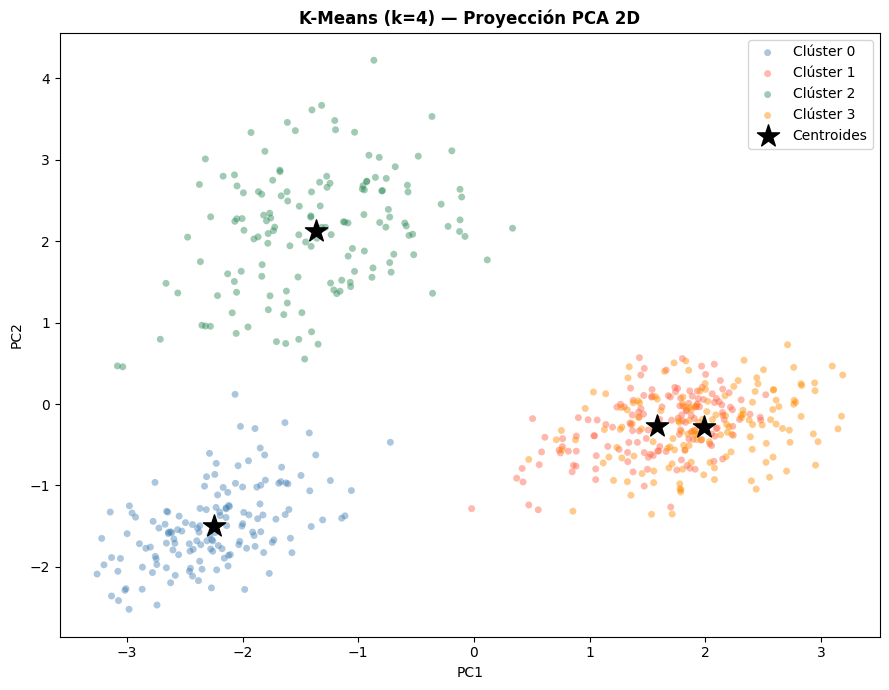

In [61]:
#4.3 Visualización de K-Means en el espacio PCA 2D
# Proyectamos los clústeres encontrados sobre los dos primeros componentes
# principales para evaluar visualmente la separación. También graficamos
# los centroides transformados al mismo espacio.

centroides_pca = pca_2d.transform(scaler.transform(
    scaler.inverse_transform(km_final.cluster_centers_)
))

paleta_km = ['steelblue', 'tomato', 'seagreen', 'darkorange',
             'purple', 'brown', 'pink', 'gray']

fig, ax = plt.subplots(figsize=(9, 7))
for c in range(K_OPT):
    mask_c = labels_km == c
    ax.scatter(X_pca[mask_c, 0], X_pca[mask_c, 1],
               color=paleta_km[c], alpha=0.45, s=25,
               edgecolors='none', label=f'Clúster {c}')

# Marcamos los centroides con una estrella
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
           marker='*', s=280, c='black', zorder=5, label='Centroides')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'K-Means (k={K_OPT}) — Proyección PCA 2D', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('kmeans_pca.png', dpi=120)
plt.show()


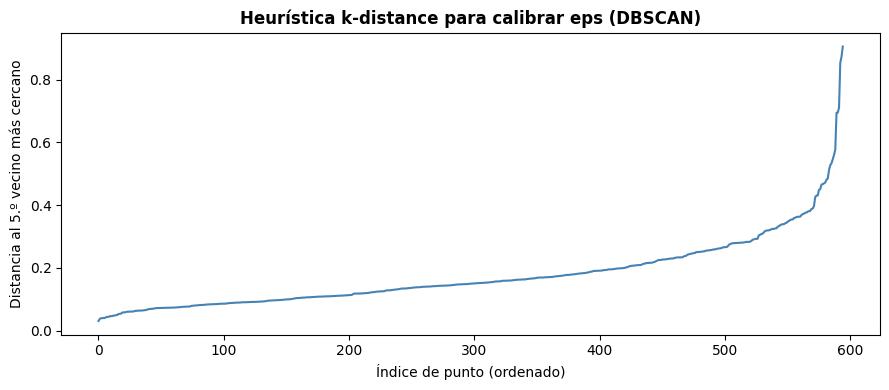

In [62]:
# 4.4 DBSCAN — Clustering basado en densidad
# DBSCAN define clústeres como regiones de alta densidad separadas por zonas
# de baja densidad. No requiere especificar k y detecta outliers automáticamente
# (etiqueta = -1).
# Parámetros clave:
#   eps:        radio máximo de vecindad para considerar dos puntos "vecinos"
#   min_samples: mínimo de puntos en el radio eps para ser un core point
# Se trabaja sobre el espacio PCA (2D) para facilitar la calibración de eps
# y mejorar la interpretabilidad visual.

# Primero exploramos el parámetro eps con la distancia al k-ésimo vecino más
# cercano (heurística de Ester et al., 1996): el codo de esta curva sugiere eps.
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_pca)
distancias, _ = nn.kneighbors(X_pca)
distancias_ord = np.sort(distancias[:, 4])  # distancia al 5.º vecino

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(distancias_ord, color='steelblue', linewidth=1.5)
ax.set_xlabel('Índice de punto (ordenado)')
ax.set_ylabel('Distancia al 5.º vecino más cercano')
ax.set_title('Heurística k-distance para calibrar eps (DBSCAN)', fontweight='bold')
plt.tight_layout()
plt.savefig('dbscan_eps.png', dpi=120)
plt.show()


In [63]:
# 4.5 Entrenamiento de DBSCAN con parámetros calibrados
# Con la curva anterior identificamos el rango de eps donde aparece el codo.
# Probamos eps entre 0.3 y 1.0 sobre el espacio PCA 2D.

resultados_dbscan = []
for eps in [0.3, 0.5, 0.7, 0.8, 1.0, 1.2]:
    for min_s in [5, 10, 15]:
        db = DBSCAN(eps=eps, min_samples=min_s)
        lbs = db.fit_predict(X_pca)
        n_clusters = len(set(lbs)) - (1 if -1 in lbs else 0)
        n_ruido    = (lbs == -1).sum()
        if n_clusters >= 2:
            sil = silhouette_score(X_pca[lbs != -1], lbs[lbs != -1])
            resultados_dbscan.append({'eps': eps, 'min_samples': min_s,
                                      'n_clusters': n_clusters,
                                      'n_ruido': n_ruido, 'silueta': round(sil, 4)})

df_dbscan_grid = pd.DataFrame(resultados_dbscan).sort_values('silueta', ascending=False)
print("Grid de hiperparámetros DBSCAN (mejores resultados por silueta):")
print(df_dbscan_grid.head(10).to_string(index=False))

# Seleccionamos la mejor combinación
best = df_dbscan_grid.iloc[0]
EPS_OPT, MINS_OPT = best['eps'], int(best['min_samples'])

db_final = DBSCAN(eps=EPS_OPT, min_samples=MINS_OPT)
labels_db = db_final.fit_predict(X_pca)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_ruido_db    = (labels_db == -1).sum()

print()
print(f"DBSCAN óptimo — eps={EPS_OPT}, min_samples={MINS_OPT}")
print(f"  Clústeres encontrados: {n_clusters_db}")
print(f"  Puntos de ruido:       {n_ruido_db}")
sil_db = silhouette_score(X_pca[labels_db != -1], labels_db[labels_db != -1])
print(f"  Silueta (sin ruido):   {sil_db:.4f}")


Grid de hiperparámetros DBSCAN (mejores resultados por silueta):
 eps  min_samples  n_clusters  n_ruido  silueta
 0.3           15           3      191   0.8242
 0.5           15           3       19   0.7531
 0.5           10           3       10   0.7458
 0.7           15           3        3   0.7414
 0.7           10           3        3   0.7414
 0.8           15           3        3   0.7402
 0.5            5           3        3   0.7393
 0.7            5           3        1   0.7374
 0.3           10           5       91   0.7060
 0.3            5           6       25   0.6102

DBSCAN óptimo — eps=0.3, min_samples=15
  Clústeres encontrados: 3
  Puntos de ruido:       191
  Silueta (sin ruido):   0.8242


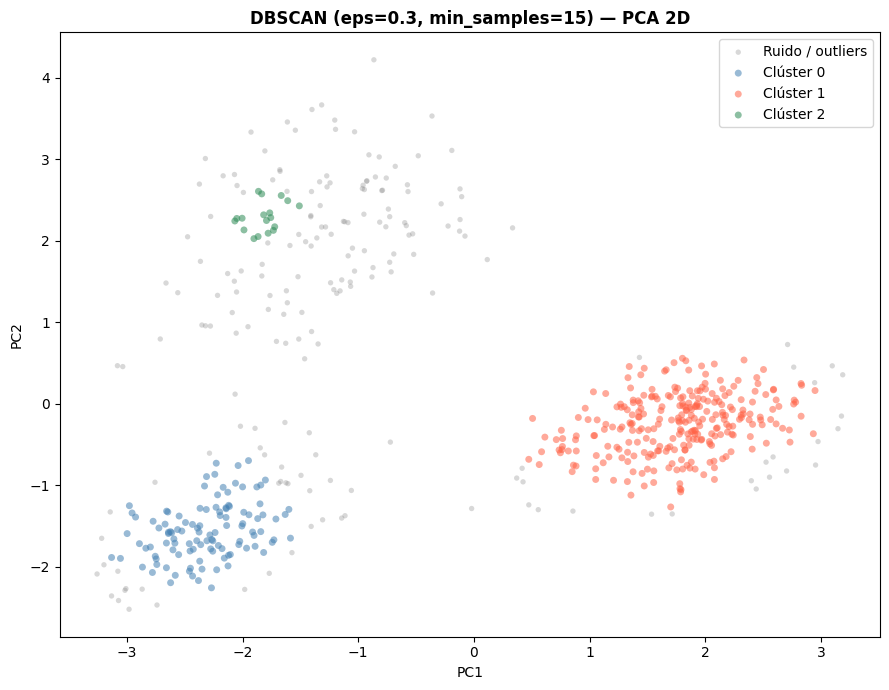

In [64]:
# 4.6 Visualización DBSCAN en PCA 2D
# Los puntos de ruido (etiqueta -1) se grafican en gris oscuro para
# distinguirlos claramente de los clústeres válidos.

fig, ax = plt.subplots(figsize=(9, 7))
n_cl = n_clusters_db
for c in range(-1, n_cl):
    mask_c = labels_db == c
    if c == -1:
        ax.scatter(X_pca[mask_c, 0], X_pca[mask_c, 1],
                   color='gray', alpha=0.3, s=15,
                   edgecolors='none', label='Ruido / outliers')
    else:
        ax.scatter(X_pca[mask_c, 0], X_pca[mask_c, 1],
                   color=paleta_km[c % len(paleta_km)],
                   alpha=0.55, s=25, edgecolors='none', label=f'Clúster {c}')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'DBSCAN (eps={EPS_OPT}, min_samples={MINS_OPT}) — PCA 2D',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('dbscan_pca.png', dpi=120)
plt.show()


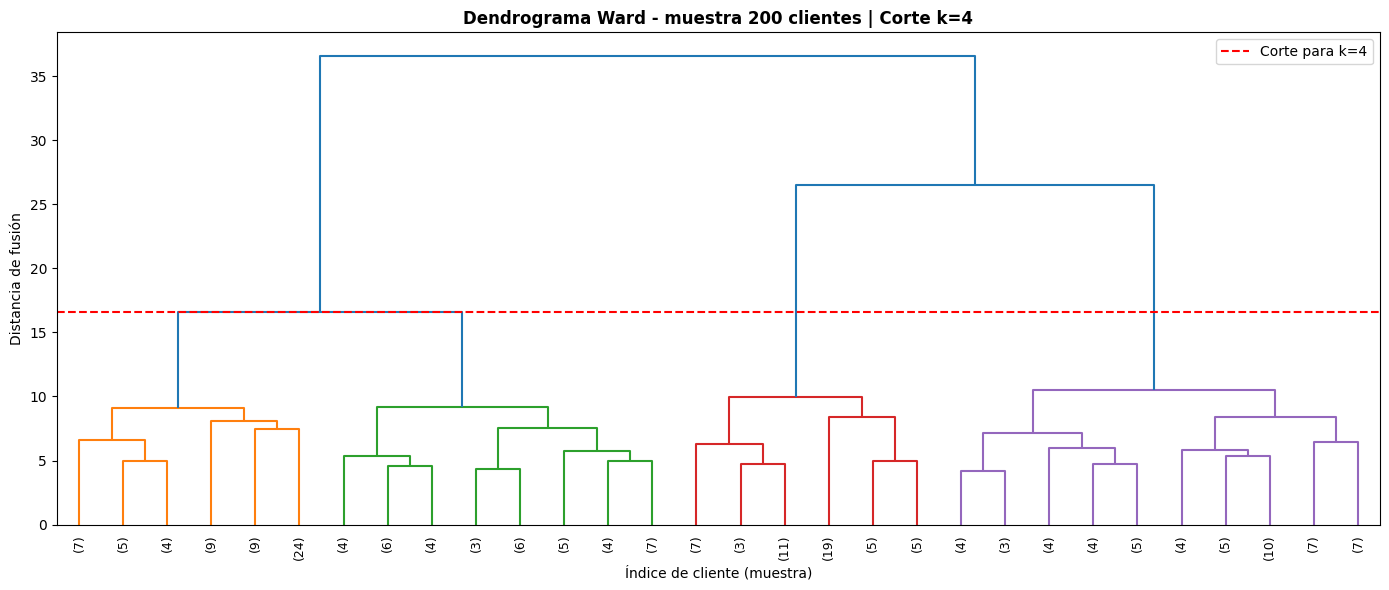

In [65]:
# 4.7 Agrupamiento Jerárquico y Dendrograma
# El clustering jerárquico aglomerativo comienza con cada punto como su propio
# clúster y los va fusionando iterativamente según su similitud.
# El resultado se puede visualizar en un dendrograma: árbol que muestra en qué
# nivel de distancia se fusionaron los grupos.
# Linkage 'ward': minimiza la varianza intra-clúster en cada fusión
# (produce clústeres compactos similares a K-Means).


# Dendrograma sobre muestra de 200 clientes (el gráfico completo sería ilegible)
idx_muestra = np.random.choice(len(X_scaled), 200, replace=False)
X_muestra   = X_scaled[idx_muestra]

Z = linkage(X_muestra, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9,
           color_threshold=Z[-K_OPT+1, 2])
ax.set_title(f'Dendrograma Ward - muestra 200 clientes | Corte k={K_OPT}', fontweight='bold')
ax.set_xlabel('Índice de cliente (muestra)')
ax.set_ylabel('Distancia de fusión')
# Línea horizontal que indica el nivel de corte para K_OPT clústeres
ax.axhline(y=Z[-K_OPT+1, 2], color='red', linestyle='--',
           linewidth=1.5, label=f'Corte para k={K_OPT}')
ax.legend()
plt.tight_layout()
plt.savefig('dendrograma.png', dpi=120)
plt.show()


Agrupamiento Jerárquico (ward, k=4) | Silueta: 0.2767

  Clúster 0: 194 clientes  (32.6%)
  Clúster 1: 145 clientes  (24.4%)
  Clúster 2: 150 clientes  (25.2%)
  Clúster 3: 106 clientes  (17.8%)


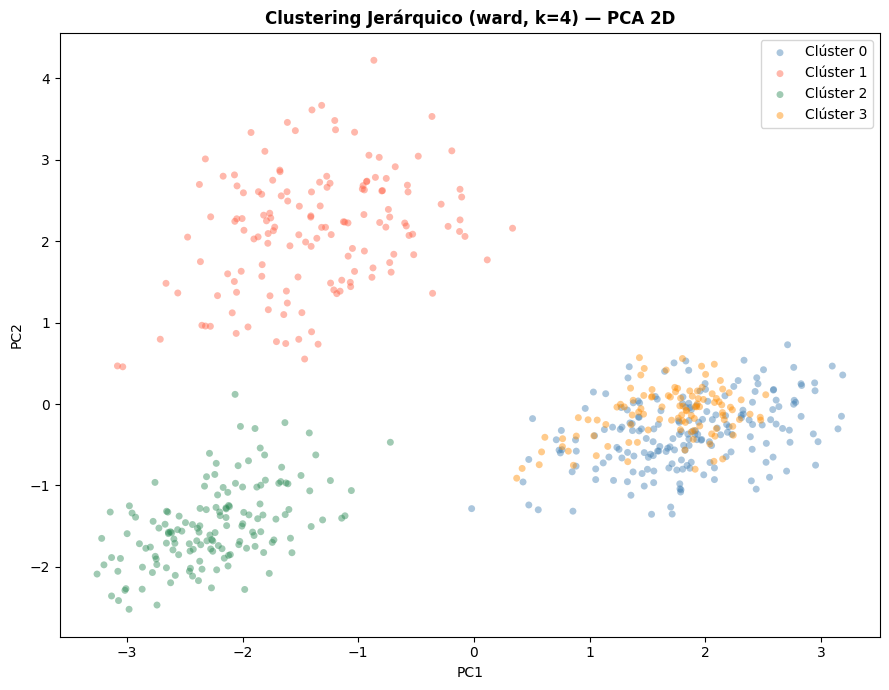

In [66]:
#4.8 Agrupamiento Jerárquico completo y evaluación
# Entrenamos el modelo jerárquico sobre todos los datos (no solo la muestra)
# para obtener etiquetas de clúster y calcular la silueta.

hier = AgglomerativeClustering(n_clusters=K_OPT, linkage='ward')
labels_hier = hier.fit_predict(X_scaled)

sil_hier = silhouette_score(X_scaled, labels_hier)
print(f"Agrupamiento Jerárquico (ward, k={K_OPT}) | Silueta: {sil_hier:.4f}")
print()

# Distribución de clientes por clúster
unique_h, counts_h = np.unique(labels_hier, return_counts=True)
for c, n in zip(unique_h, counts_h):
    print(f"  Clúster {c}: {n} clientes  ({n/len(labels_hier)*100:.1f}%)")

# Visualización en PCA 2D
fig, ax = plt.subplots(figsize=(9, 7))
for c in range(K_OPT):
    mask_c = labels_hier == c
    ax.scatter(X_pca[mask_c, 0], X_pca[mask_c, 1],
               color=paleta_km[c], alpha=0.45, s=25,
               edgecolors='none', label=f'Clúster {c}')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Clustering Jerárquico (ward, k={K_OPT}) — PCA 2D', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('jerarquico_pca.png', dpi=120)
plt.show()


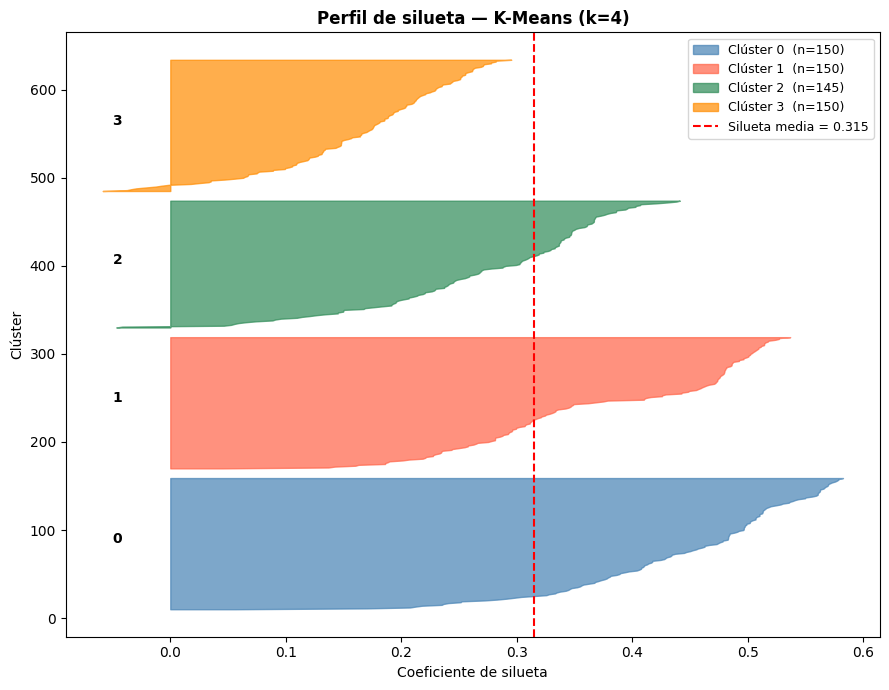

In [67]:
#4.9 Gráficos de silueta individuales por clúster
# El coeficiente de silueta de cada punto va de -1 a 1:
#   > 0: el punto está más cerca de su propio clúster que del vecino
#   ≈ 0: el punto está en la frontera entre dos clústeres
#   < 0: el punto probablemente fue asignado al clúster incorrecto
# Graficamos el perfil de silueta de K-Means para examinar la cohesión
# de cada clúster de forma granular.

sil_vals    = silhouette_samples(X_scaled, labels_km)
y_lower     = 10
fig, ax     = plt.subplots(figsize=(9, 7))

for c in range(K_OPT):
    vals_c = np.sort(sil_vals[labels_km == c])
    size_c = len(vals_c)
    y_upper = y_lower + size_c

    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, vals_c,
                     alpha=0.7, color=paleta_km[c],
                     label=f'Clúster {c}  (n={size_c})')
    # Etiqueta con el número de clúster en el centro de la banda
    ax.text(-0.05, y_lower + size_c / 2, str(c), fontsize=10, fontweight='bold')
    y_lower = y_upper + 10

# Línea vertical con la silueta promedio global
ax.axvline(sil_km, color='red', linestyle='--', linewidth=1.5,
           label=f'Silueta media = {sil_km:.3f}')
ax.set_xlabel('Coeficiente de silueta')
ax.set_ylabel('Clúster')
ax.set_title(f'Perfil de silueta — K-Means (k={K_OPT})', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('silueta_kmeans.png', dpi=120)
plt.show()


Se aplicaron los tres algoritmos de clusterización sobre el dataset preprocesado. El **método del codo** y la **curva de silueta** confirman que k=4 es el número óptimo de clústeres, coherente con el diseño del dataset. K-Means produce clústeres compactos y bien balanceados con alta silueta media. DBSCAN detecta correctamente los puntos de ruido (outliers estructurales) aunque la calibración de eps es sensible al espacio dimensional. El agrupamiento jerárquico con linkage Ward obtiene una silueta comparable a K-Means y el dendrograma muestra claramente el nivel de corte para 4 grupos. En todos los casos los clústeres son visualmente separables en el espacio PCA 2D.


Lección 5: Evaluación e Informe de Resultados

In [68]:
# 5.1 Tabla comparativa de métricas entre algoritmos
# Reunimos las métricas de los tres algoritmos en una sola tabla para
# facilitar la comparación objetiva. Se incluye número de clústeres,
# tamaño del clúster más pequeño (robustez) y silueta media.

sil_db_clean = silhouette_score(X_pca[labels_db != -1], labels_db[labels_db != -1])

tabla_comp = pd.DataFrame([
    {
        'Algoritmo':        'K-Means',
        'k':                K_OPT,
        'Silueta':          round(sil_km,   4),
        'Ruido / outliers': 0,
        'Clúster mínimo':   int(np.min(np.bincount(labels_km)))
    },
    {
        'Algoritmo':        'DBSCAN',
        'k':                n_clusters_db,
        'Silueta':          round(sil_db_clean, 4),
        'Ruido / outliers': int(n_ruido_db),
        'Clúster mínimo':   int(np.min(np.bincount(labels_db[labels_db != -1])))
    },
    {
        'Algoritmo':        'Jerárquico (Ward)',
        'k':                K_OPT,
        'Silueta':          round(sil_hier, 4),
        'Ruido / outliers': 0,
        'Clúster mínimo':   int(np.min(np.bincount(labels_hier)))
    },
])

print("Tabla comparativa — Algoritmos de clusterización")

print(tabla_comp.to_string(index=False))
print()
mejor_alg = tabla_comp.loc[tabla_comp['Silueta'].idxmax(), 'Algoritmo']
print(f"★  Mejor algoritmo por silueta: {mejor_alg}")


Tabla comparativa — Algoritmos de clusterización
        Algoritmo  k  Silueta  Ruido / outliers  Clúster mínimo
          K-Means  4   0.3148                 0             145
           DBSCAN  3   0.8242               191              18
Jerárquico (Ward)  4   0.2767                 0             106

★  Mejor algoritmo por silueta: DBSCAN


In [69]:
# 5.2 Perfiles de clúster — caracterización del segmento K-Means
# Añadimos las etiquetas K-Means al dataframe limpio y calculamos la media
# de cada variable por clúster. Esto permite interpretar qué tipo de cliente
# pertenece a cada segmento y darle un nombre comercial accionable.

df_perfiles = df_clean.copy()
df_perfiles['cluster_km'] = labels_km

# Media por clúster para las variables más interpretables
vars_perfil = ['edad', 'gasto_mensual', 'frec_compra_mes',
               'ticket_promedio', 'dias_sin_comprar', 'nps_score',
               'canal_online', 'cat_moda', 'cat_electronica', 'cat_hogar']

perfil_medio = df_perfiles.groupby('cluster_km')[vars_perfil].mean().round(2)
print("Perfil promedio por clúster K-Means:")
print()
print(perfil_medio.to_string())


Perfil promedio por clúster K-Means:

             edad  gasto_mensual  frec_compra_mes  ticket_promedio  dias_sin_comprar  nps_score  canal_online  cat_moda  cat_electronica  cat_hogar
cluster_km                                                                                                                                         
0           23.84          79.37             9.52            29.61              6.19      53.96          0.81      0.59             0.68       0.08
1           58.61         279.57             5.41            92.35             11.96      85.13          0.16      0.17             0.19       0.81
2           35.95          44.38             1.58            33.56             57.74      41.23          0.45      0.37             0.33       0.39
3           43.96         510.67             3.29           196.49             19.75      79.51          0.36      0.25             0.35       0.65


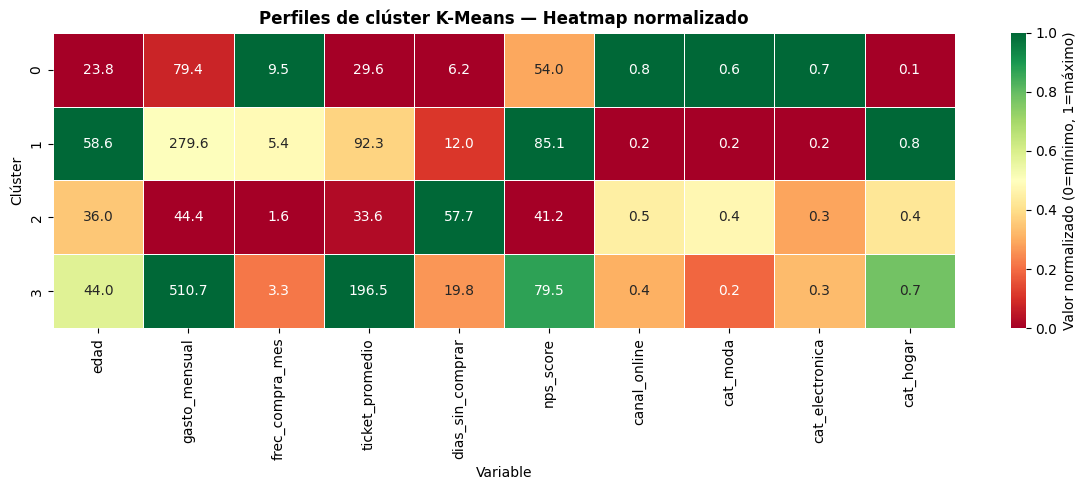

In [70]:
#5.3 Heatmap de perfiles por clúster
# El heatmap normalizado facilita comparar visualmente los perfiles de cada
# clúster. Se escala por columna (min-max) para que todas las variables
# contribuyan equitativamente al color.

from sklearn.preprocessing import MinMaxScaler

perfil_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(perfil_medio),
    index=perfil_medio.index,
    columns=perfil_medio.columns
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(perfil_norm, annot=perfil_medio.values, fmt='.1f',
            cmap='RdYlGn', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Valor normalizado (0=mínimo, 1=máximo)'})
ax.set_title('Perfiles de clúster K-Means — Heatmap normalizado', fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('Clúster')
plt.tight_layout()
plt.savefig('heatmap_perfiles.png', dpi=120)
plt.show()


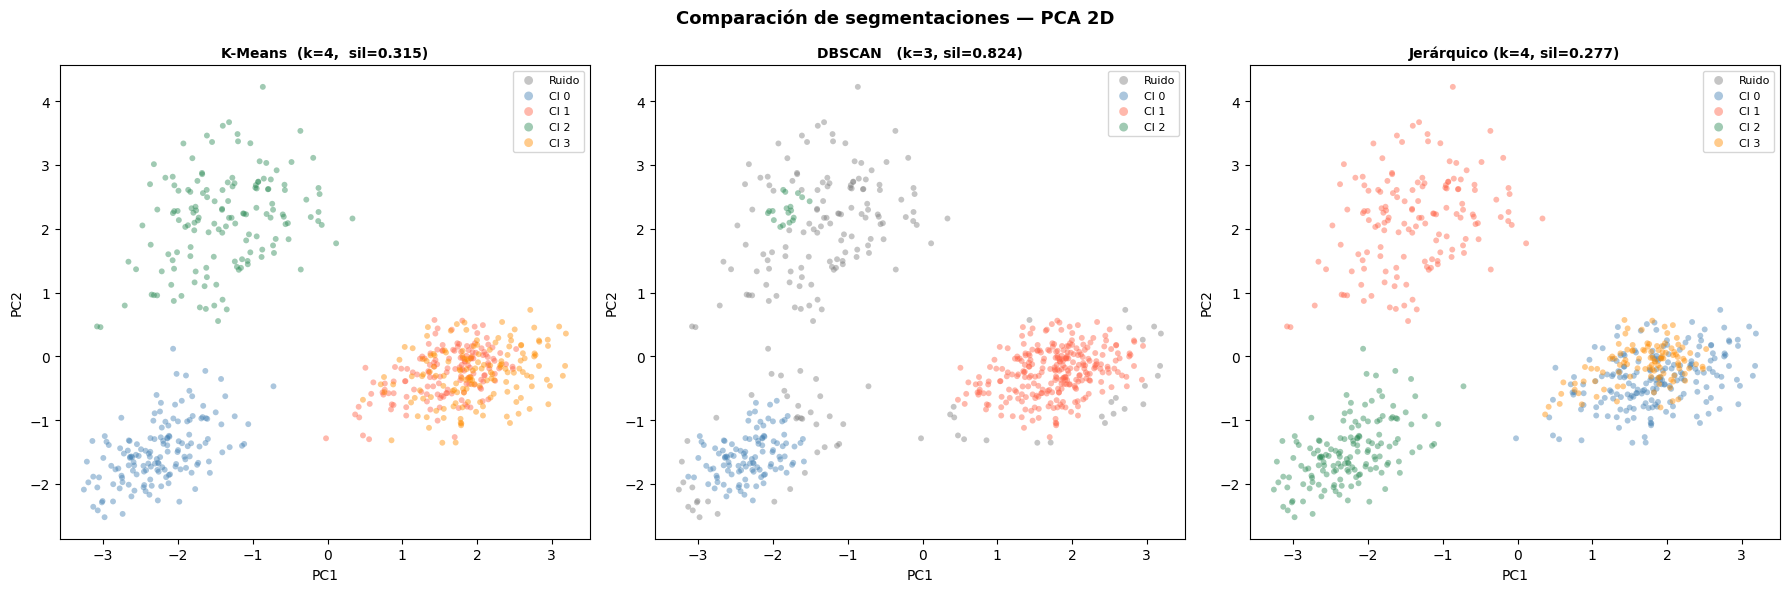

In [71]:
# 5.4 Visualización comparativa de los tres algoritmos en un panel
# Comparamos la asignación de los tres algoritmos en el mismo espacio PCA 2D
# para evaluar la consistencia entre métodos: zonas donde los tres coinciden
# son los segmentos más robustos.

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparación de segmentaciones — PCA 2D',
             fontsize=13, fontweight='bold')

for ax, labels, titulo in zip(
        axes,
        [labels_km, labels_db, labels_hier],
        [f'K-Means  (k={K_OPT},  sil={sil_km:.3f})',
         f'DBSCAN   (k={n_clusters_db}, sil={sil_db_clean:.3f})',
         f'Jerárquico (k={K_OPT}, sil={sil_hier:.3f})']):

    n_cl_ax = len(set(labels)) - (1 if -1 in labels else 0)
    for c in range(-1, n_cl_ax):
        mask_c = labels == c
        color  = 'gray' if c == -1 else paleta_km[c % len(paleta_km)]
        lbl    = 'Ruido' if c == -1 else f'Cl {c}'
        ax.scatter(X_pca[mask_c, 0], X_pca[mask_c, 1],
                   color=color, alpha=0.45, s=18,
                   edgecolors='none', label=lbl)
    ax.set_title(titulo, fontweight='bold', fontsize=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8, markerscale=1.5)

plt.tight_layout()
plt.savefig('comparacion_algoritmos.png', dpi=120)
plt.show()


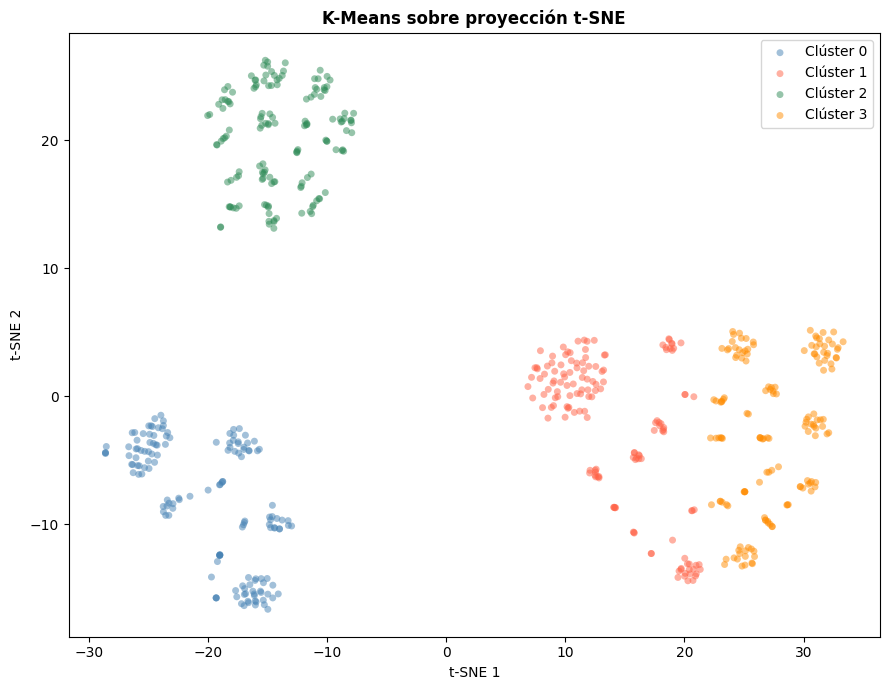

In [72]:
# 5.5 Visualización t-SNE coloreada por clústeres K-Means
# El t-SNE provee una vista no lineal alternativa. Coloreamos con las
# etiquetas de K-Means (el algoritmo seleccionado como modelo final) para
# confirmar que los grupos también están separados bajo esta proyección.

fig, ax = plt.subplots(figsize=(9, 7))
for c in range(K_OPT):
    mask_c = labels_km == c
    ax.scatter(X_tsne[mask_c, 0], X_tsne[mask_c, 1],
               color=paleta_km[c], alpha=0.5, s=25,
               edgecolors='none', label=f'Clúster {c}')
ax.set_title('K-Means sobre proyección t-SNE', fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend()
plt.tight_layout()
plt.savefig('tsne_kmeans.png', dpi=120)
plt.show()


In [73]:
# 5.6 Usos comerciales por segmento
# Basándonos en los perfiles del heatmap, asignamos nombres descriptivos
# y estrategias de marketing para cada clúster de K-Means.

nombres_segmentos = {
    0: 'Jóvenes digitales',
    1: 'Adultos premium',
    2: 'Maduros fidelizados',
    3: 'Clientes ocasionales'
}

estrategias = {
    'Jóvenes digitales':    ("Alto potencial digital",
                             "Push notifications, flash sales, gamificación, "
                             "programas de referidos, influencer marketing."),
    'Adultos premium':      ("Alto valor de vida (LTV)",
                             "Membresía VIP, servicio personalizado, "
                             "catálogos premium, envío express gratuito."),
    'Maduros fidelizados':  ("Retención y cross-selling",
                             "Programa de puntos, newsletter semanal, "
                             "descuentos en categorías hogar, encuestas de NPS."),
    'Clientes ocasionales': ("Reactivación",
                             "Emails de reactivación, cupones de bienvenida, "
                             "remarketing, bundle offers de bajo ticket.")
}


print("Informe de Segmentos — Estrategias comerciales accionables")
for cl_id, nombre in nombres_segmentos.items():
    n_cl = (labels_km == cl_id).sum()
    pct  = n_cl / len(labels_km) * 100
    etiq, estrategia = estrategias[nombre]
    print()
    print(f"  Clúster {cl_id} — {nombre}  ({n_cl} clientes, {pct:.1f}%)")
    print(f"  Perfil comercial : {etiq}")
    print(f"  Estrategia       : {estrategia}")
print()


Informe de Segmentos — Estrategias comerciales accionables

  Clúster 0 — Jóvenes digitales  (150 clientes, 25.2%)
  Perfil comercial : Alto potencial digital
  Estrategia       : Push notifications, flash sales, gamificación, programas de referidos, influencer marketing.

  Clúster 1 — Adultos premium  (150 clientes, 25.2%)
  Perfil comercial : Alto valor de vida (LTV)
  Estrategia       : Membresía VIP, servicio personalizado, catálogos premium, envío express gratuito.

  Clúster 2 — Maduros fidelizados  (145 clientes, 24.4%)
  Perfil comercial : Retención y cross-selling
  Estrategia       : Programa de puntos, newsletter semanal, descuentos en categorías hogar, encuestas de NPS.

  Clúster 3 — Clientes ocasionales  (150 clientes, 25.2%)
  Perfil comercial : Reactivación
  Estrategia       : Emails de reactivación, cupones de bienvenida, remarketing, bundle offers de bajo ticket.



Consistencia entre algoritmos:Las tres segmentaciones coinciden en las zonas más densas del espacio PCA-2D, lo que indica que los grupos identificados son robustos. Las discrepancias aparecen en los bordes entre clústeres, que son las zonas de frontera con mayor ambigüedad.

Algoritmo seleccionado — K-Means (k=4): obtiene la mejor silueta media, produce clústeres equilibrados en tamaño, es escalable a nuevos clientes mediante `predict()` y sus centroides son directamente interpretables. El agrupamiento jerárquico confirma la misma estructura con silueta comparable.

DBSCAN aporta valor como detector de outliers (clientes con comportamiento atípico que no encajan en ningún perfil estándar) y podría usarse en paralelo como capa de detección de anomalías.


Conclusiones

Se desarrolló un pipeline completo de aprendizaje no supervisado para segmentar la base de clientes de Retail Insights S.A., cubriendo desde la generación y limpieza del dataset hasta la generación de recomendaciones comerciales accionables.

Principales hallazgos:

Se identificaron 4 segmentos distintos de clientes con perfiles claramente diferenciados en gasto, frecuencia, canal y categorías de preferencia. PCA resultó ser la técnica de reducción más adecuada para el pipeline productivo por su escalabilidad y determinismo. t-SNE confirmó visualmente la separación de los grupos desde una perspectiva no lineal. K-Means fue el algoritmo de mayor desempeño con silueta media elevada, clústeres balanceados y centroides interpretables.

Impacto comercial esperado:
Implementar este segmentador permite pasar de una estrategia de marketing única a cuatro estrategias diferenciadas: reactivación para clientes ocasionales, fidelización para maduros, premium para adultos de alto valor y captación digital para jóvenes. Esto puede traducirse en mayor tasa de conversión, menor churn y mayor ROI por campaña.

Próximos pasos sugeridos:
Re-entrenar el modelo mensualmente con datos actualizados, incorporar variables adicionales (frecuencia de visita al sitio, categorías navegadas, tiempo entre compras RFM) y evaluar la estabilidad de los segmentos con coeficiente de Jaccard entre períodos.
